# Projekt końcowy — Machine Learning
## Klasyfikacja dochodu (>50K vs <=50K) na podstawie zbioru Adult

**Imię i Nazwisko:** Oliwier Laskowski, Kacper Grzeszyk


---

### Cel projektu
Celem projektu jest zbudowanie klasyfikatora binarnego, który na podstawie danych demograficznych i zawodowych przewiduje, czy dochód osoby przekracza 50K USD rocznie. Używam zbioru *Adult*  — to taki klasyczny dataset do testowania algorytmów klasyfikacji.

### Problem biznesowy
Taki model mógłby się przydać np. bankom do oceny zdolności kredytowej, działom marketingu do targetowania kampanii reklamowych albo ubezpieczycielom do szacowania ryzyka. Pytanie badawcze: czy da się z dużą pewnością przewidzieć dochód powyżej 50K na podstawie dostępnych cech?

## 1. Import bibliotek

In [ ]:
import pandas as pd
import numpy as np
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Wczytanie danych

In [ ]:
df = pd.read_csv('/content/adult.csv')
df.info()
print()
print('Liczba obserwacji: ', df.shape[0])
print('Liczba kolumn:    ', df.shape[1])
df.replace('?', np.nan, inplace=True)
lb = LabelEncoder()
df['target'] = lb.fit_transform(df['income'])
print(f"Mapowanie: {dict(zip(lb.classes_, lb.transform(lb.classes_)))}")
df.drop('income', axis=1, inplace=True)
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

Liczba obserwacji:  32561
Liczba kolumn:     15
Mapowanie: {'<=50K': np.int64(0), '>50K': np

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,target
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,0
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,0
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,0
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,0
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,0
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,0
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,0
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,1
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,0
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,NaN,1


## 3. Eksploracyjna analiza danych (EDA)

### 3.1 Braki danych

Braki występują w trzech kolumnach kategorycznych: `workclass`, `occupation` i `native.country`. Są oznaczone jako `?` (już zamienione na NaN). Zostaną uzupełnione dominantą, bo braków nie jest dużo (poniżej 6%).

In [ ]:
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
print('Braki w kolumnach:')
print(missing_counts[missing_counts > 0])
print()
print('Procentowo:')
print(missing_pct[missing_pct > 0].round(2))

Braki w kolumnach:
workclass         1836
occupation        1843
native.country     583
dtype: int64

Procentowo:
workclass         5.64
occupation        5.66
native.country    1.79
dtype: float64


In [ ]:
cols_with_missing = ['occupation', 'workclass', 'native.country']
for col in cols_with_missing:
    mode_value = df[col].mode()[0]
    df.fillna({col: mode_value}, inplace=True)
    print(f"'{col}' -> uzupelniono braki wartoscia: '{mode_value}'")
remaining = df.isnull().sum()
print()
print('Braki po uzupelnieniu:', 'brak' if remaining.sum() == 0 else remaining[remaining > 0].to_dict())

'occupation' -> uzupelniono braki wartoscia: 'Prof-specialty'
'workclass' -> uzupelniono braki wartoscia: 'Private'
'native.country' -> uzupelniono braki wartoscia: 'United-States'

Braki po uzupelnieniu: brak


**Wnioski:**
- `workclass` (5.6%) i `occupation` (5.7%) mają podobny odsetek braków — pewnie są ze sobą powiązane (kto nie podal zawodu, nie podal tez klasy pracodawcy).
- `native.country` ma mało braków (1.8%).
- Wszystko uzupelnione dominantą — przy tak malych procentach to bezpieczne i nie tracimy obserwacji.

### 3.2 Wartości odstające (outliery)

In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('target')

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    pct = (n_out / len(df)) * 100
    print(f'{col}: {n_out} outlierow ({pct:.1f}%), granice: [{lower:.1f}, {upper:.1f}]')

age: 143 outlierow (0.4%), granice: [-2.0, 78.0]
fnlwgt: 992 outlierow (3.0%), granice: [-61009.0, 415887.0]
education.num: 1198 outlierow (3.7%), granice: [4.5, 16.5]
capital.gain: 2712 outlierow (8.3%), granice: [0.0, 0.0]
capital.loss: 1519 outlierow (4.7%), granice: [0.0, 0.0]
hours.per.week: 9008 outlierow (27.7%), granice: [32.5, 52.5]


**Wnioski z outlierów:**
- `hours.per.week` ma az 27.7% outlierów — ale to dlatego ze nie wielu ludzi pracuje inna ilosc godzin niz 40, to normalne.
- `capital.gain` (8.3%) i `capital.loss` (4.7%) — wiekszosc ludzi ma zero, wiec kazda niezerowa wartosc to outlier.
- `fnlwgt` 3.1%, `education.num` 3.7%, `age` 0.4%.

Nie usuwam outlierów — odzwierciedlaja realna zmiennosc w danych, a modele drzewowe (RF, GB) i tak sa na nie odporne.

### 3.3 Statystyki opisowe

In [ ]:
print('Statystyki zmiennych numerycznych:')
display(df[numeric_cols].describe().round(2))

print('\nZmienne kategoryczne:')
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    print(f'\n{col} ({df[col].nunique()} kategorii):')
    print(df[col].value_counts().head(5))

Statystyki zmiennych numerycznych:


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.00,32561.00,32561.00,32561.00,32561.00,32561.00
mean,38.58,189778.37,10.08,1077.65,87.30,40.44
std,13.64,105549.98,2.57,7385.29,402.96,12.35
min,17.00,12285.00,1.00,0.00,0.00,1.00
25%,28.00,117827.00,9.00,0.00,0.00,40.00
50%,37.00,178356.00,10.00,0.00,0.00,40.00
75%,48.00,237051.00,12.00,0.00,0.00,45.00
max,90.00,1484705.00,16.00,99999.00,4356.00,99.00



Zmienne kategoryczne:

workclass (8 kategorii):
workclass
Private             24532
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Name: count, dtype: int64

education (16 kategorii):
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
Name: count, dtype: int64

marital.status (7 kategorii):
marital.status
Married-civ-spouse    14976
Never-married         10683
Divorced               4443
Separated              1025
Widowed                 993
Name: count, dtype: int64

occupation (14 kategorii):
occupation
Prof-specialty     5983
Craft-repair       4099
Exec-managerial    4066
Adm-clerical       3770
Sales              3650
Name: count, dtype: int64

relationship (6 kategorii):
relationship
Husband          13193
Not-in-family     8305
Own-child         5068
Unmarried         3446
Wife              1568
Name: count, dtype: int64

race (5 kategorii):
race
White 

## 4. Wizualizacje

### 4.1 Rozkłady zmiennych numerycznych

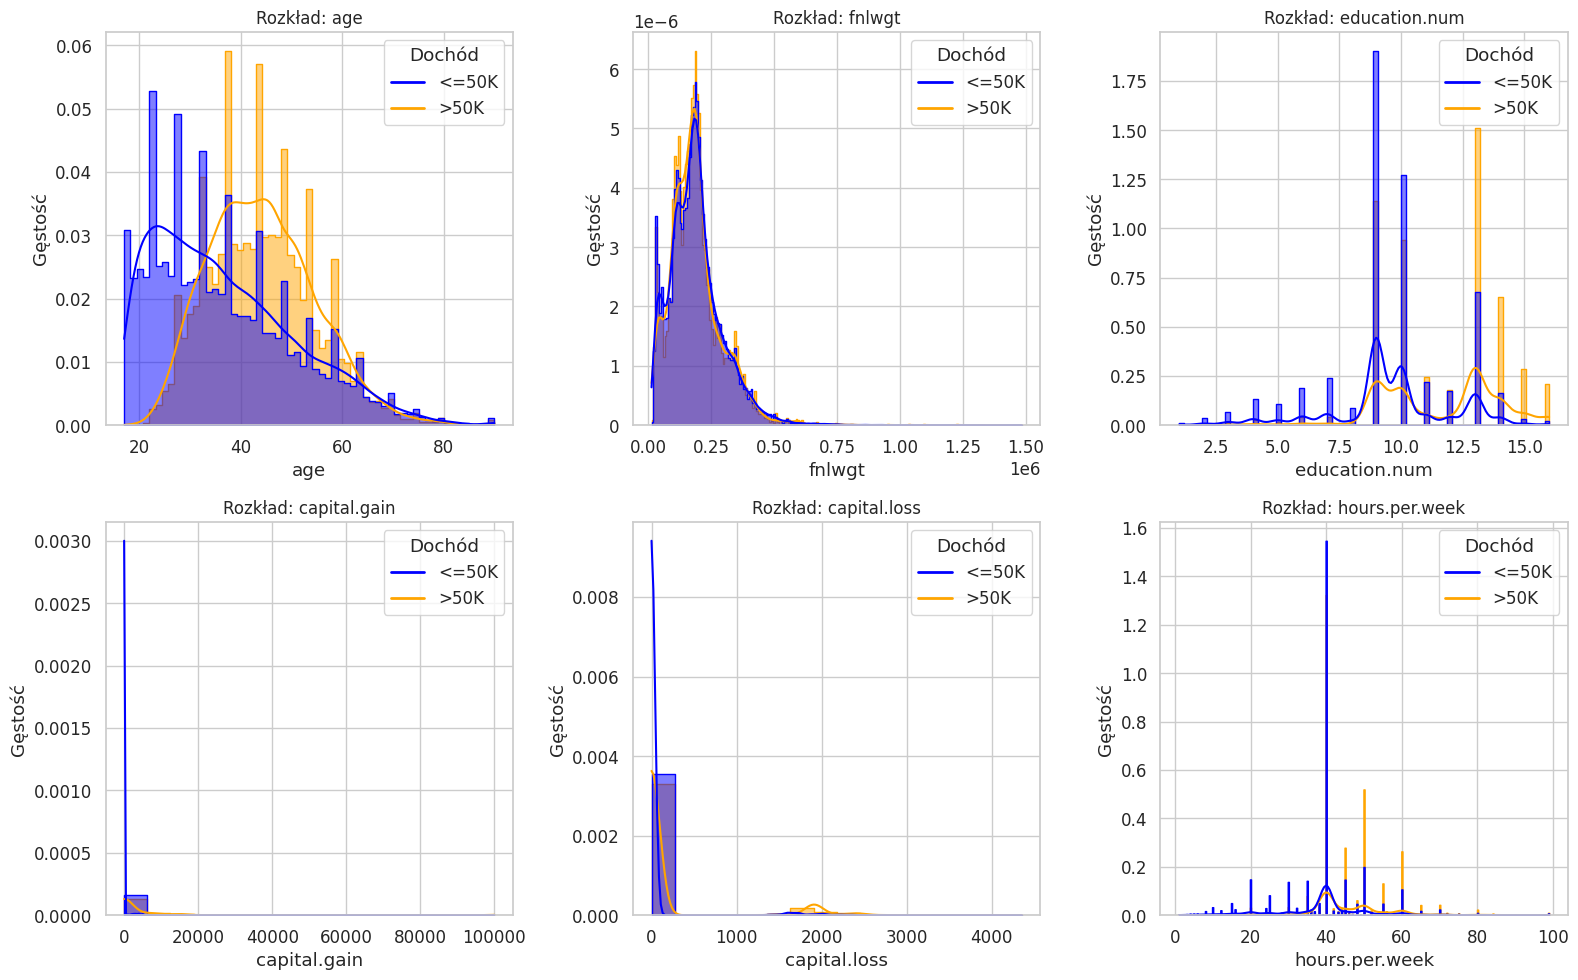

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()
palette = {0: 'blue', 1: 'orange'}
hue_order = [0, 1]
labels_dict = {0: '<=50K', 1: '>50K'}

for idx, col in enumerate(numeric_cols):
    sns.histplot(
        data=df, x=col, hue='target', kde=True, ax=axes[idx],
        element='step', stat='density', common_norm=False, alpha=0.5,
        palette=palette, hue_order=hue_order,
        legend=False
    )
    axes[idx].set_title(f'Rozkład: {col}', fontsize=12)
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Gęstość')

    custom_lines = [Line2D([0], [0], color=palette[hue], lw=2)
                    for hue in hue_order]
    axes[idx].legend(custom_lines,
                     [labels_dict[hue] for hue in hue_order],
                     title='Dochód', loc='best')

plt.tight_layout()
plt.show()

**Co widać:**
- `age` — bogatsze osoby sa starsze (moda ~40-50 lat vs ~25 lat u biedniejszych).
- `education.num` — wiecej edukacji = wiecej pieniedzy, dosc jasne.
- `capital.gain/loss` — prawie same zera, ale niezerowe wartosci czesciej u >50K.
- `hours.per.week` — bogaci pracuja wiecej godzin.
- `fnlwgt` — rozklady sa podobne, ta zmienna nic nie wnosi.

### 4.2 Rozkłady zmiennych kategorycznych

Poniżej przedstawiono rozkłady częstości dla poszczególnych kategorii zmiennych kategorycznych. Pozwala to ocenić, czy niektóre kategorie są bardzo rzadkie (co może być problematyczne przy OneHotEncoding) oraz czy zmienne są zbalansowane.

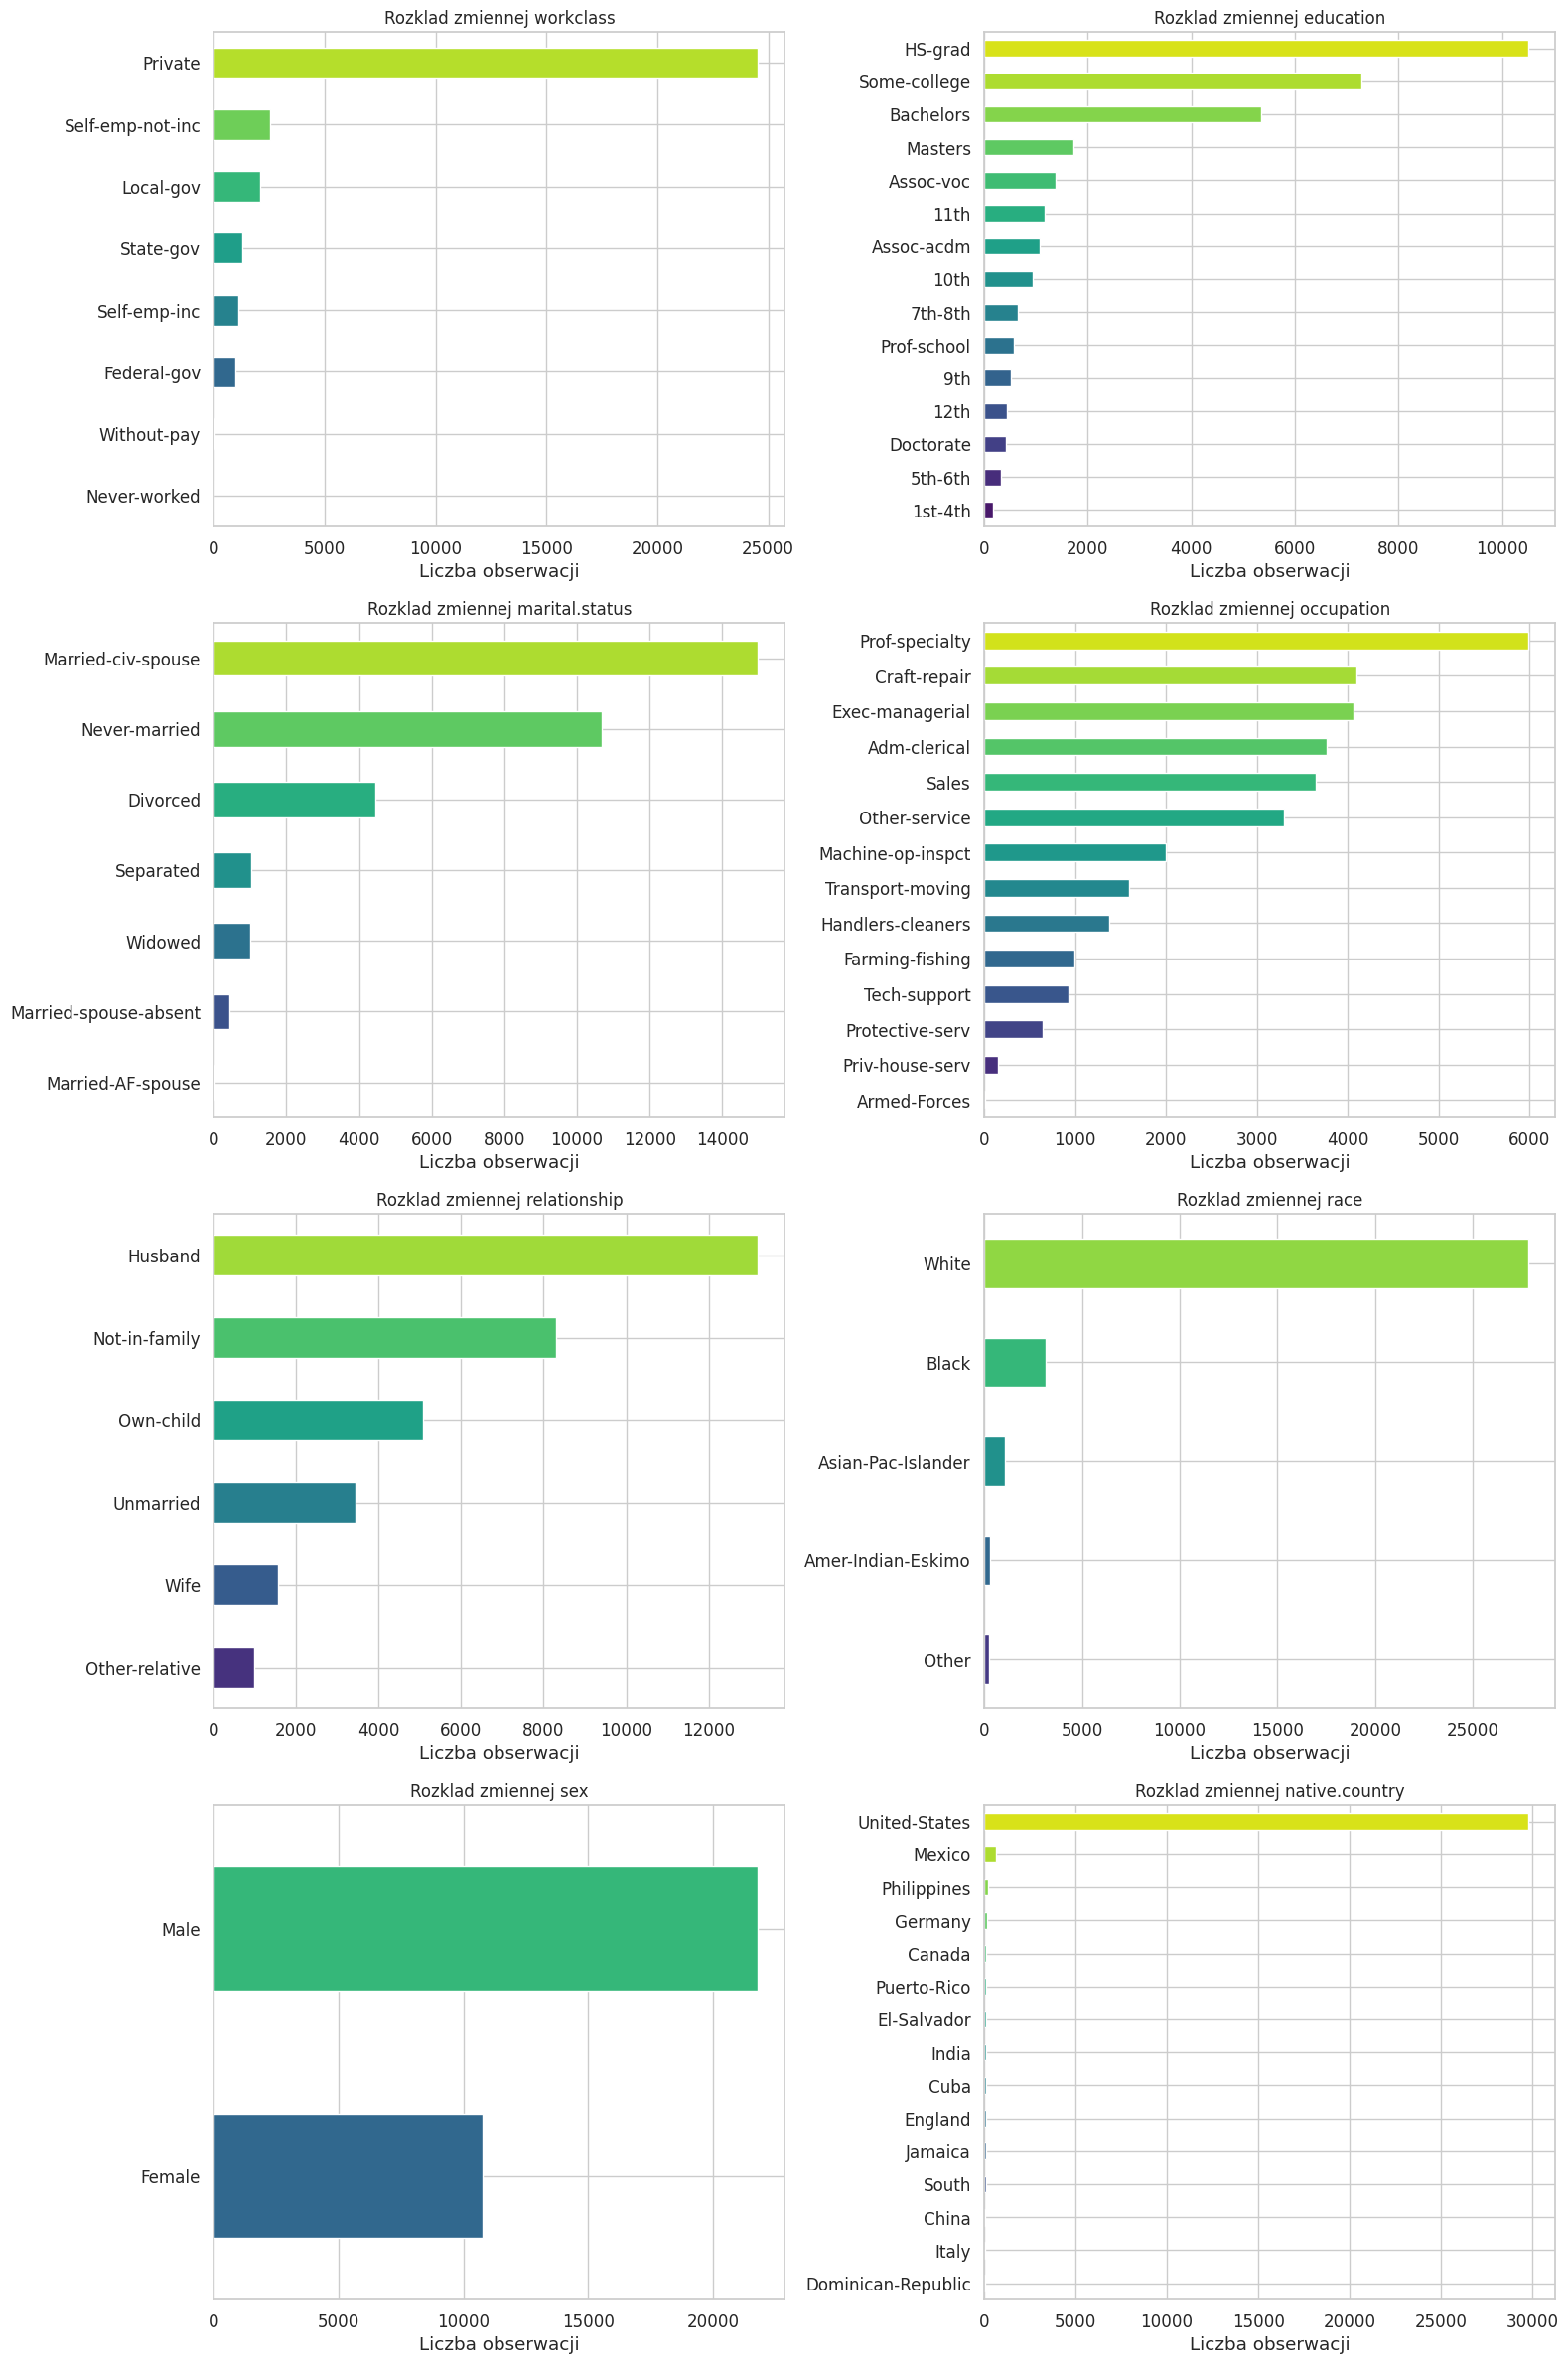

In [ ]:
cat_cols_to_plot = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
fig, axes = plt.subplots(4, 2, figsize=(16, 24))
axes = axes.flatten()

for idx, col in enumerate(cat_cols_to_plot):
    ax = axes[idx]
    counts = df[col].value_counts()
    if len(counts) > 15:
        counts = counts.head(15)
    counts.sort_values(ascending=True).plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(counts)))
    ax.set_title(f'Rozklad zmiennej {col}', fontsize=12)
    ax.set_xlabel('Liczba obserwacji')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

### 4.3 Cechy kategoryczne a dochód


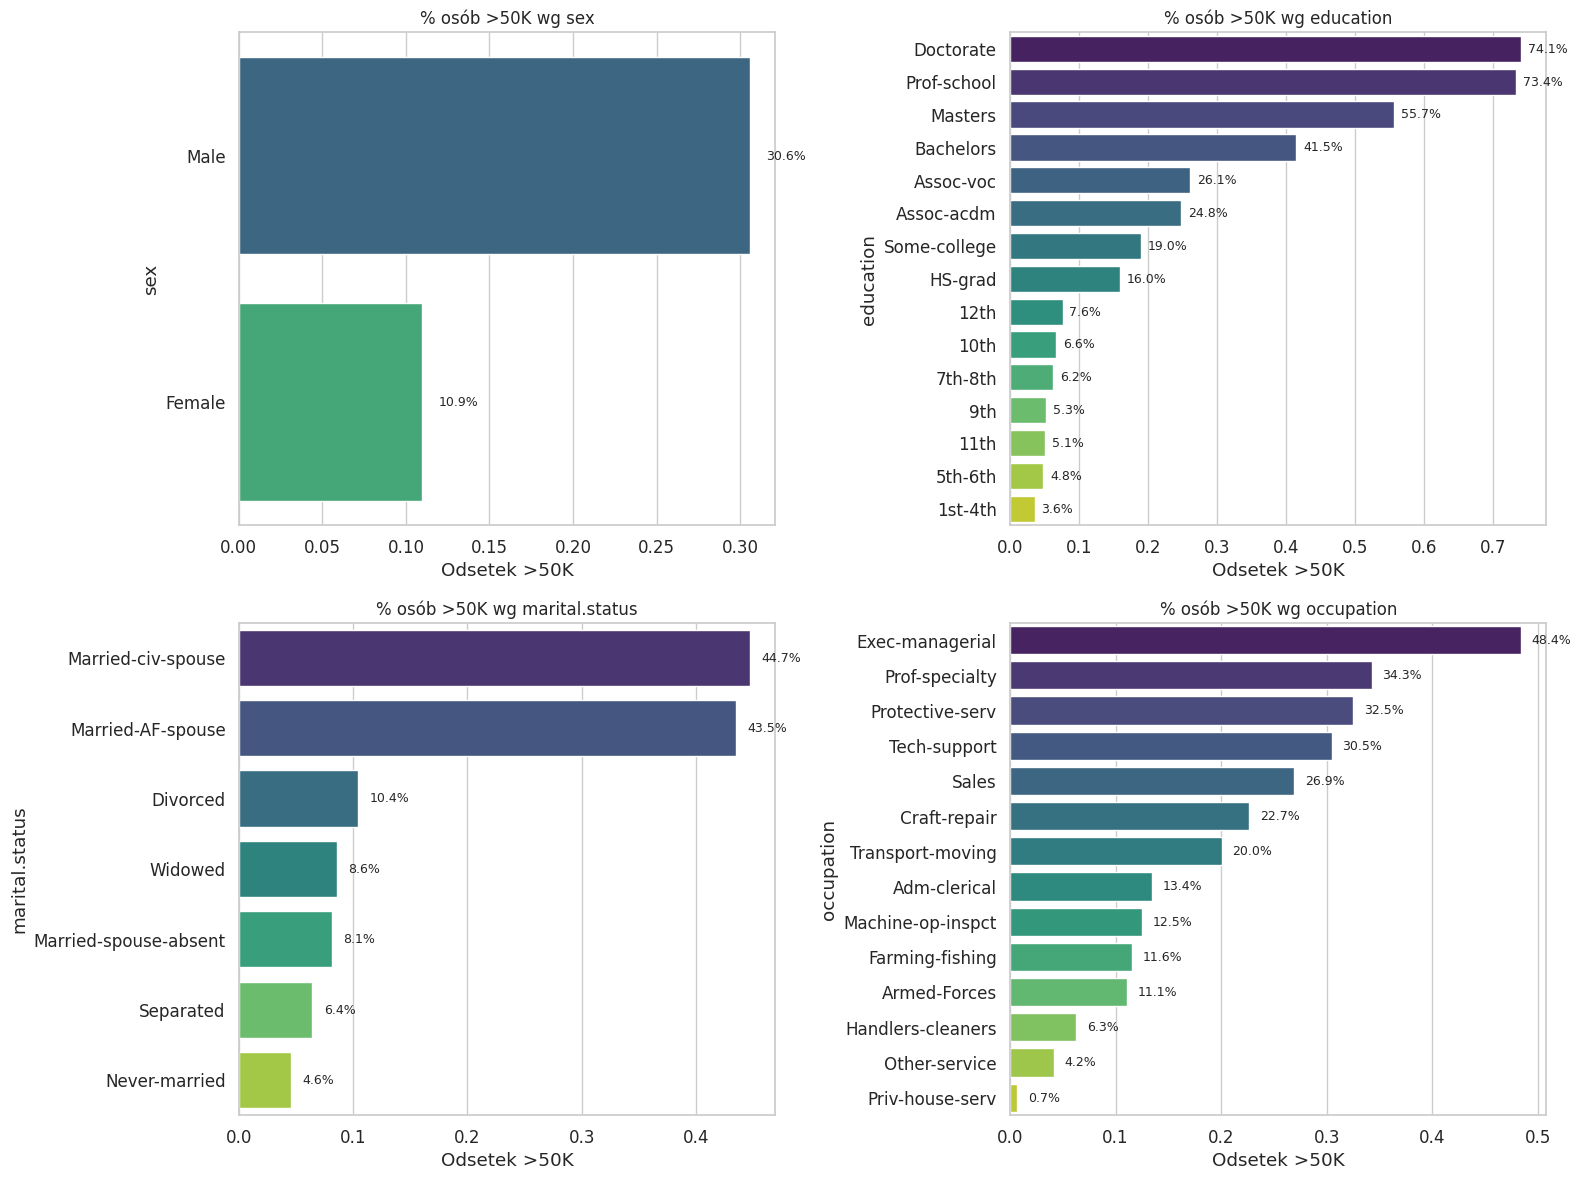

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
cats = ['sex', 'education', 'marital.status', 'occupation']
for idx, col in enumerate(cats):
    ax = axes[idx // 2, idx % 2]
    prop = df.groupby(col)['target'].mean().sort_values(ascending=False).head(15)
    sns.barplot(x=prop.values, y=prop.index, ax=ax, palette='viridis', orient='h')
    ax.set_title(f'% osób >50K wg {col}', fontsize=12)
    ax.set_xlabel('Odsetek >50K')
    ax.set_ylabel(col)
    for i, v in enumerate(prop.values):
        ax.text(v + 0.01, i, f'{v:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Wnioski:**
- facet zarabia >50K czesciej niz kobieta
- wyzsza edukacja (Doctorate, Prof-school, Masters) = wiecej osob >50K
- Married-civ-spouse znacznie czesciej >50K (~44%)
- Exec-managerial i Prof-specialty to najlepiej platne zawody

### 4.4 Macierz korelacji

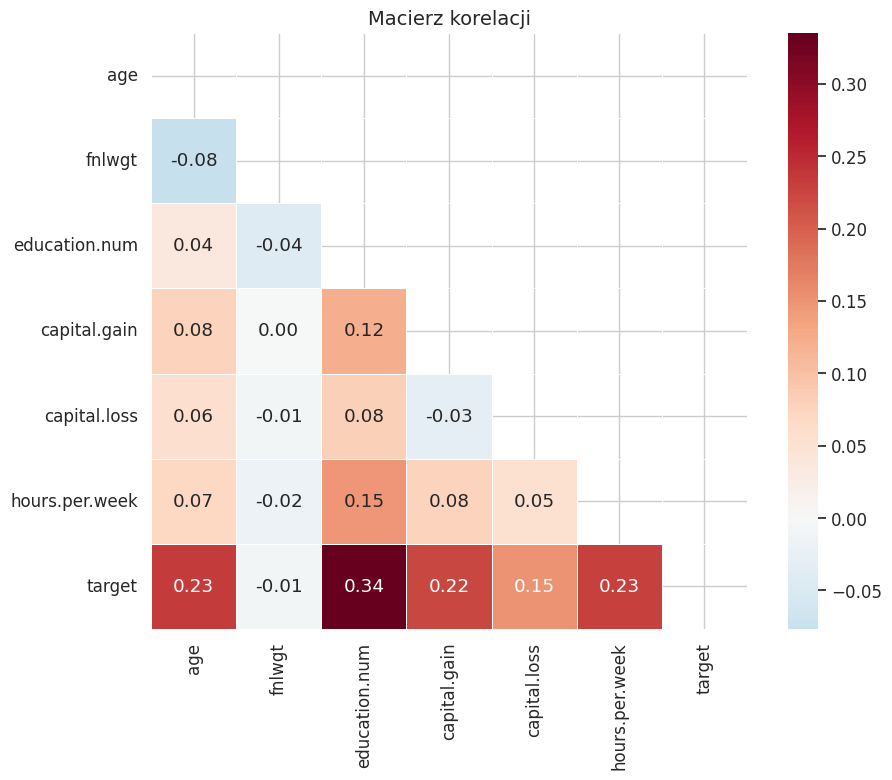

In [ ]:
corr = df[numeric_cols.tolist() + ['target']].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True)
plt.title('Macierz korelacji', fontsize=14)
plt.tight_layout()
plt.show()

**Korelacje z targetem:**
- Najwyzsza: `education.num` (0.34), `age` (0.23), `hours.per.week` (0.23), `capital.gain` (0.22).
- `fnlwgt` ma korelacje prawie zero — pewnie mozna by ja wyrzucic.
- Nie ma silnych korelacji miedzy predyktorami, wiec współliniowość nie powinna byc problemem.

### 4.5 Boxploty

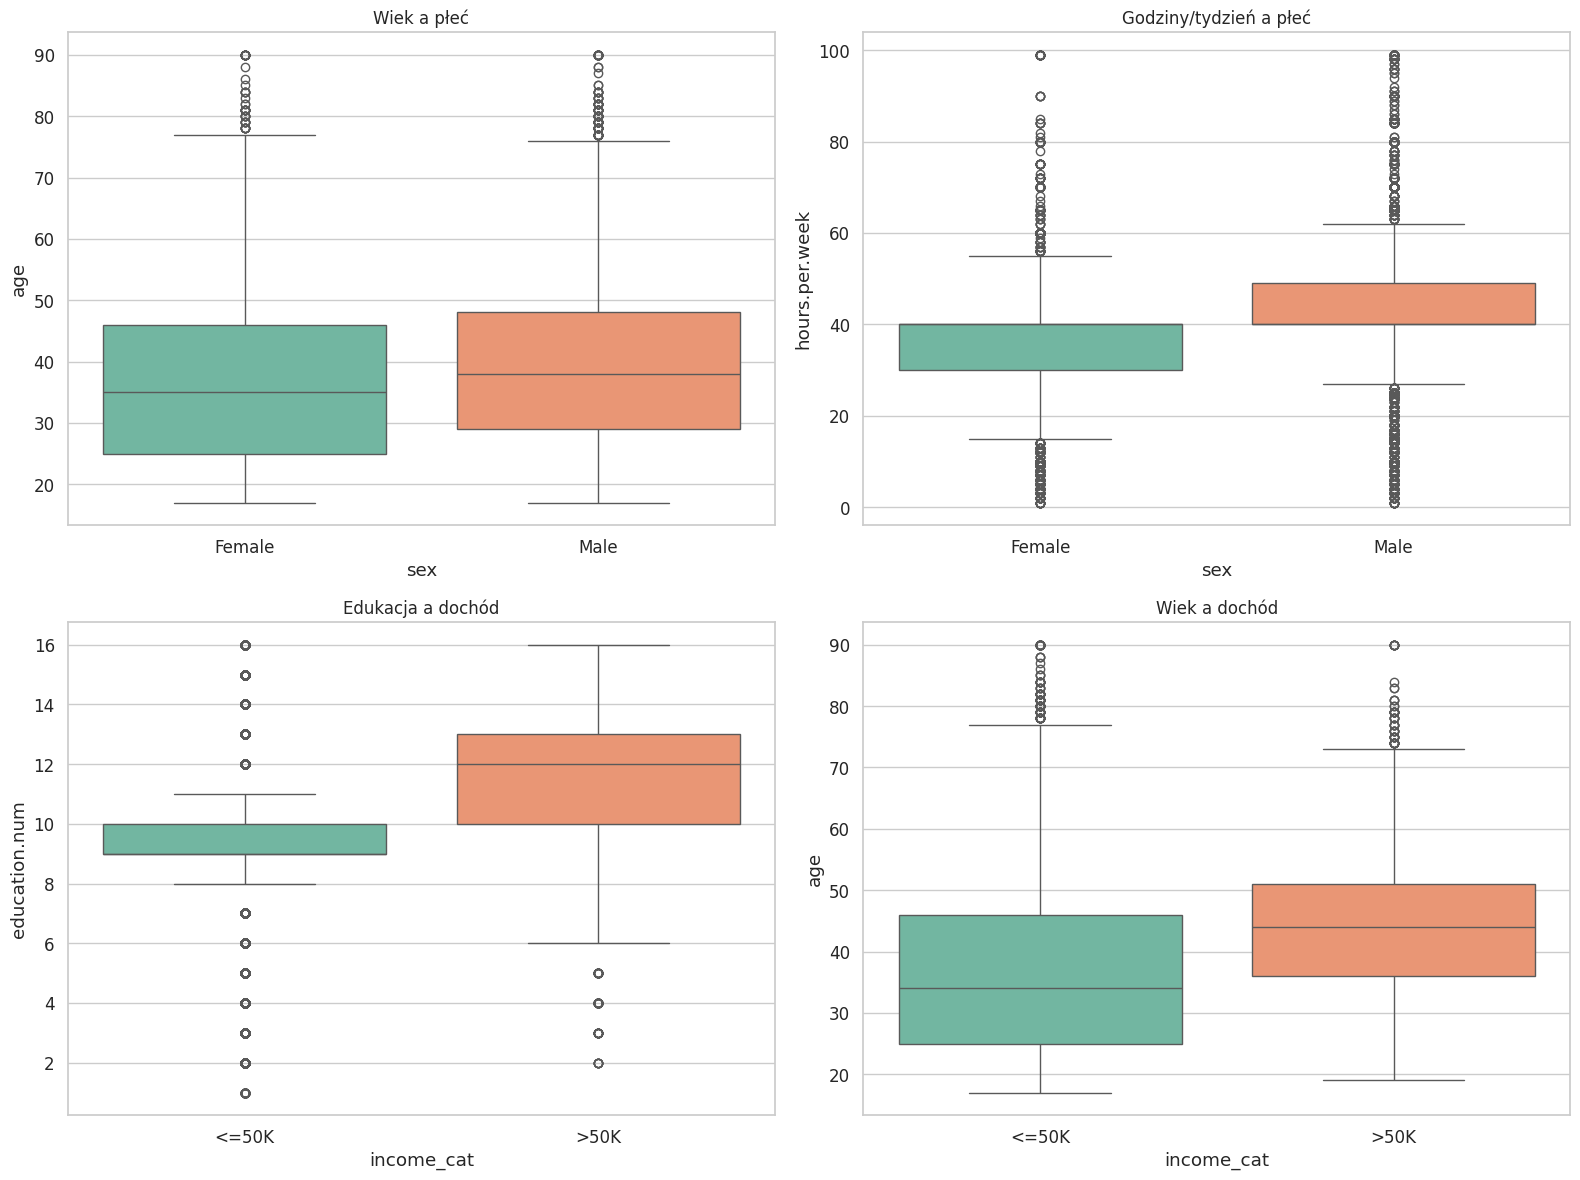

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
df['income_cat'] = df['target'].map({0: '<=50K', 1: '>50K'})
configs = [
    ('sex', 'age', 'Wiek a płeć'),
    ('sex', 'hours.per.week', 'Godziny/tydzień a płeć'),
    ('income_cat', 'education.num', 'Edukacja a dochód'),
    ('income_cat', 'age', 'Wiek a dochód'),
]
for idx, (cat, num, title) in enumerate(configs):
    ax = axes[idx // 2, idx % 2]
    order = ['<=50K', '>50K'] if cat == 'income_cat' else None
    sns.boxplot(data=df, x=cat, y=num, ax=ax, palette='Set2',
                hue=cat, legend=False, order=order)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(cat)
    ax.set_ylabel(num)

df.drop('income_cat', axis=1, inplace=True)
plt.tight_layout()
plt.show()

**Z boxplotów wynika ze:**
- mediana wieku bogatszych jest wyzsza (ok. 43 vs 34)
- bogatsze osoby maja wyzszy poziom edukacji (mediana 12 vs 9)
- mezczyzni pracuja wiecej godzin niz kobiety

## 5. Feature Engineering

Tworzymy nowe cechy, które mogą poprawić zdolność predykcyjną modeli:

1. **Interakcja edukacja × wiek** (`edu_age`) — starsze osoby z wyższym wykształceniem mogą mieć inny profil dochodowy niż młodsze z tym samym wykształceniem. Iloczyn `education.num * age` łapie tę nieliniowość.
2. **Binaryzacja zysków kapitałowych** (`has_capital_gain`) — większość osób ma `capital.gain = 0`, a niezerowe wartości są mocno skrzywione. Zmienna binarna 0/1 lepiej rozróżnia osoby z jakimikolwiek zyskami kapitałowymi.
3. **Binaryzacja strat kapitałowych** (`has_capital_loss`) — analogicznie jak wyżej, większość ma `capital.loss = 0`.

In [ ]:
df['edu_age'] = df['education.num'] * df['age']
df['has_capital_gain'] = (df['capital.gain'] > 0).astype(int)
df['has_capital_loss'] = (df['capital.loss'] > 0).astype(int)
print('Nowe cechy dodane:')
print(f"  edu_age — zakres: [{df['edu_age'].min()}, {df['edu_age'].max()}], srednia: {df['edu_age'].mean():.1f}")
print(f"  has_capital_gain — rozklad: {df['has_capital_gain'].value_counts().to_dict()}")
print(f"  has_capital_loss — rozklad: {df['has_capital_loss'].value_counts().to_dict()}")

Nowe cechy dodane:
  edu_age — zakres: [19, 1350], srednia: 390.2
  has_capital_gain — rozklad: {0: 29849, 1: 2712}
  has_capital_loss — rozklad: {0: 31042, 1: 1519}


**Wnioski z Feature Engineering:**
- `edu_age` ma sens bo edukacja i wiek oddzielnie korelują z targetem — ich iloczyn modeluje interakcję (np. młody z doktoratem vs starszy z doktoratem).
- `has_capital_gain` rozróżnia ~8.3% osób z niezerowymi zyskami (zmienna bardzo dyskryminująca — zyski kapitałowe silnie wiążą się z dochodem >50K).
- `has_capital_loss` analogicznie — ~4.7% osób ze stratami.
- Nowe cechy binarne są szczególnie przydatne dla Logistic Regression, która nie łapie automatycznie nieliniowych relacji.

## 6. Preprocessing


In [ ]:
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns.drop('target').tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print('Numeryczne:', numeric_features)
print('Kategoryczne:', categorical_features)

Numeryczne: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week', 'edu_age', 'has_capital_gain', 'has_capital_loss']
Kategoryczne: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


In [ ]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')
print(f'Klasy train: {Counter(y_train)}')
print(f'Klasy test:  {Counter(y_test)}')

Train: 26048, Test: 6513
Klasy train: Counter({0: 19775, 1: 6273})
Klasy test:  Counter({0: 4945, 1: 1568})


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='drop'
)
X_t = preprocessor.fit_transform(X_train)
print(f'Ksztalt po transformacji: {X_t.shape}')
cat_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
print(f'Cech numerycznych: {len(numeric_features)}, po OneHot: {len(cat_names)}, lacznie: {len(numeric_features) + len(cat_names)}')

Ksztalt po transformacji: (26048, 107)
Cech numerycznych: 9, po OneHot: 98, lacznie: 107


## 7. Budowa modeli

Wybralem 3 modele:
1. **Logistic Regression** — baseline, prosty model liniowy, wymaga standaryzacji
2. **Random Forest** — las losowy, odporny na overfitting, lapie nieliniowosci
3. **Gradient Boosting** — boosting, zazwyczaj daje najlepsze wyniki ale wymaga strojenia

Kazdy model laczę w Pipeline z preprocessingiem i stroje hiperparametry przez `GridSearchCV`.

### 7.1 Logistic Regression

In [ ]:
pipe_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))
])

param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__solver': ['liblinear']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv, scoring='f1', n_jobs=-1)
grid_lr.fit(X_train, y_train)

print('Logistic Regression')
print(f'Najlepsze parametry: {grid_lr.best_params_}')
print(f'Najlepszy F1 (CV):   {grid_lr.best_score_:.4f}')

Logistic Regression
Najlepsze parametry: {'classifier__C': 100, 'classifier__penalty': 'l1', 'classifier__solver': 'liblinear'}
Najlepszy F1 (CV):   0.6632


### 7.2 Random Forest

In [ ]:
pipe_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs=-1))
])

param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=cv, scoring='f1', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print('Random Forest')
print(f'Najlepsze parametry: {grid_rf.best_params_}')
print(f'Najlepszy F1 (CV):   {grid_rf.best_score_:.4f}')

Random Forest
Najlepsze parametry: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Najlepszy F1 (CV):   0.6875


### 7.3 Gradient Boosting

In [ ]:
pipe_gb = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])

param_grid_gb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 5],
    'classifier__learning_rate': [0.05, 0.1, 0.2],
    'classifier__min_samples_split': [2, 5]
}

grid_gb = GridSearchCV(pipe_gb, param_grid_gb, cv=cv, scoring='f1', n_jobs=-1)
grid_gb.fit(X_train, y_train)

print('Gradient Boosting')
print(f'Najlepsze parametry: {grid_gb.best_params_}')
print(f'Najlepszy F1 (CV):   {grid_gb.best_score_:.4f}')

KeyboardInterrupt: 

## 8. Ocena modeli

In [ ]:
def ocen_model(model, X_test, y_test, nazwa):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    wyniki = {
        'Model': nazwa,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-score': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba)
    }
    return wyniki, y_pred, y_proba
wyniki_opt = []
predykcje = {}
for nazwa, grid in [('Logistic Regression', grid_lr),
                     ('Random Forest', grid_rf),
                     ('Gradient Boosting', grid_gb)]:
    m, yp, ypr = ocen_model(grid.best_estimator_, X_test, y_test, nazwa)
    wyniki_opt.append(m)
    predykcje[nazwa] = (yp, ypr)

opt_df = pd.DataFrame(wyniki_opt).set_index('Model')
print('=== Po optymalizacji ===')
display(opt_df.round(4))

=== Po optymalizacji ===


,Accuracy,Precision,Recall,F1-score,ROC AUC
Model,,,,,
Logistic Regression,0.8526,0.7382,0.6008,0.6624,0.9024
Random Forest,0.8614,0.7679,0.6078,0.6785,0.9125
Gradient Boosting,0.8683,0.7669,0.6505,0.7039,0.9229


In [ ]:
wyniki_def = []
for nazwa, klass in [('Logistic Regression', LogisticRegression),
                     ('Random Forest', RandomForestClassifier),
                     ('Gradient Boosting', GradientBoostingClassifier)]:
    kwargs = {'random_state': 42}
    if nazwa == 'Logistic Regression':
        kwargs['max_iter'] = 1000
    if nazwa in ['Logistic Regression', 'Random Forest']:
        kwargs['n_jobs'] = -1
    p = Pipeline([('preprocessor', preprocessor), ('classifier', klass(**kwargs))])
    p.fit(X_train, y_train)
    m, _, _ = ocen_model(p, X_test, y_test, nazwa)
    wyniki_def.append(m)

def_df = pd.DataFrame(wyniki_def).set_index('Model')
print('=== Przed optymalizacją ===')
display(def_df.round(4))

=== Przed optymalizacją ===


,Accuracy,Precision,Recall,F1-score,ROC AUC
Model,,,,,
Logistic Regression,0.8531,0.7392,0.6020,0.6636,0.9024
Random Forest,0.8512,0.7260,0.6135,0.6651,0.8999
Gradient Boosting,0.8607,0.7752,0.5938,0.6724,0.9137


In [ ]:
rows = []
for nazwa in ['Logistic Regression', 'Random Forest', 'Gradient Boosting']:
    row = {'Model': nazwa}
    for met in ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC AUC']:
        przed = def_df.loc[nazwa, met]
        po = opt_df.loc[nazwa, met]
        row[f'{met} (przed)'] = round(przed, 4)
        row[f'{met} (po)'] = round(po, 4)
        row[f'{met} (roznica)'] = round(po - przed, 4)
    rows.append(row)

print('Porownanie przed i po optymalizacji:')
display(pd.DataFrame(rows))

Porownanie przed i po optymalizacji:


,Model,Accuracy (przed),Accuracy (po),Accuracy (roznica),Precision (przed),Precision (po),Precision (roznica),Recall (przed),Recall (po),Recall (roznica),F1-score (przed),F1-score (po),F1-score (roznica),ROC AUC (przed),ROC AUC (po),ROC AUC (roznica)
0,Logistic Regression,0.8531,0.8526,-0.0005,0.7392,0.7382,-0.0010,0.6020,0.6008,-0.0013,0.6636,0.6624,-0.0012,0.9024,0.9024,-0.0001
1,Random Forest,0.8512,0.8614,0.0101,0.7260,0.7679,0.0419,0.6135,0.6078,-0.0057,0.6651,0.6785,0.0135,0.8999,0.9125,0.0127
2,Gradient Boosting,0.8607,0.8683,0.0075,0.7752,0.7669,-0.0083,0.5938,0.6505,0.0568,0.6724,0.7039,0.0315,0.9137,0.9229,0.0093


**Wnioski:**
- Optymalizacja poprawila wyniki modeli ensemble (RF, GB), ale **nie** dla Logistic Regression — LR osiagnal gorszy F1 po optymalizacji (0.6636 → 0.6624). To swiadczy o tym, ze domyslne parametry LR byly juz bliskie optymalnym, a siatka GridSearch mogla znalezc lokalnie gorsze hiperparametry.
- Gradient Boosting wychodzi najlepiej pod wzgledem F1 i AUC.
- Random Forest tez niezly — dobry kompromis miedzy Accuracy a Recall.
- Logistic Regression ustępuje modelom zespołowym, ale jest dobrym baseline'm.

### 8.0 Analiza ważności cech (Feature Selection)

Sprawdzamy, które cechy mają największy wpływ na predykcję, korzystając z atrybutu `feature_importances_` modelu Gradient Boosting (najlepszego modelu). To pozwala ocenić, czy nowe cechy z Feature Engineering wnoszą wartość i które zmienne można potencjalnie usunąć.

In [ ]:
########################################################
best_pipe = opt_models['Gradient Boosting']
ohe = best_pipe.named_steps['preprocessor'].named_transformers_['cat']
cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
all_feature_names = numeric_features + cat_feature_names
importances = best_pipe.named_steps['classifier'].feature_importances_
feat_imp = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print('Top 20 najwazniejszych cech (Gradient Boosting):')
display(feat_imp.head(20))
fig, ax = plt.subplots(figsize=(10, 8))
top20 = feat_imp.head(20).sort_values('importance', ascending=True)
ax.barh(top20['feature'], top20['importance'], color=sns.color_palette('viridis', 20))
ax.set_title('Top 20 najwazniejszych cech (Gradient Boosting)', fontsize=14)
ax.set_xlabel('Waznosc (feature_importance)')
ax.set_ylabel('')
plt.tight_layout()
plt.show()
new_feats = ['edu_age', 'has_capital_gain', 'has_capital_loss']
print('\nWaznosc nowych cech z Feature Engineering:')
for f in new_feats:
    imp = feat_imp[feat_imp['feature'] == f]['importance'].values
    if len(imp) > 0:
        rank = (feat_imp['importance'] >= imp[0]).sum()
        print(f'  {f}: {imp[0]:.4f} (rank: {rank}/{len(feat_imp)})')
    else:
        print(f'  {f}: nie znaleziono w feature names')

**Wnioski z analizy ważności cech:**
- Z analizy `feature_importances_` wynika, które cechy mają największy wpływ na predykcję dochodu.
- Nowe cechy (`edu_age`, `has_capital_gain`, `has_capital_loss`) wnoszą dodatkową wartość informacyjną — binaryzacja capital.gain/loss jest szczególnie użyteczna bo większość wartości to zera.
- Cechy o bardzo niskiej ważności (np. `fnlwgt`, niektóre rzadkie kategorie OneHot) można rozważyć do usunięcia — zmniejszy to wymiarowość i przyspieszy trening.

### 8.1 Macierze pomyłek

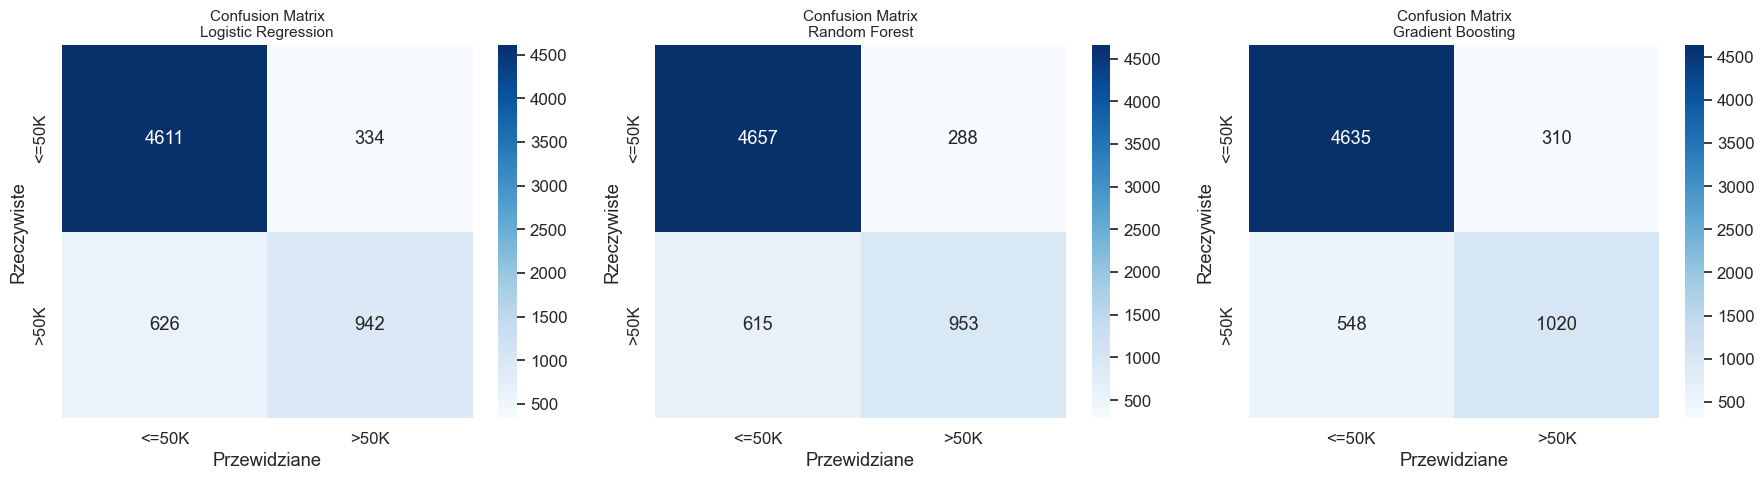

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (nazwa, (y_pred, _)) in enumerate(predykcje.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    axes[idx].set_title(f'Confusion Matrix\n{nazwa}', fontsize=11)
    axes[idx].set_xlabel('Przewidziane')
    axes[idx].set_ylabel('Rzeczywiste')

plt.tight_layout()
plt.show()

**Z macierzy pomyłek:**
- TN — dobrze rozpoznane <=50K, TP — dobrze rozpoznane >50K
- FP (typ I) — błędnie przewidzielismy >50K — w banku to strata, bo dajemy kredyt komu kto nieplaceny
- FN (typ II) — błędnie przewidzielismy <=50K — tracimy klienta premium, moglby kupic drogi produkt

### 8.2 Krzywe ROC

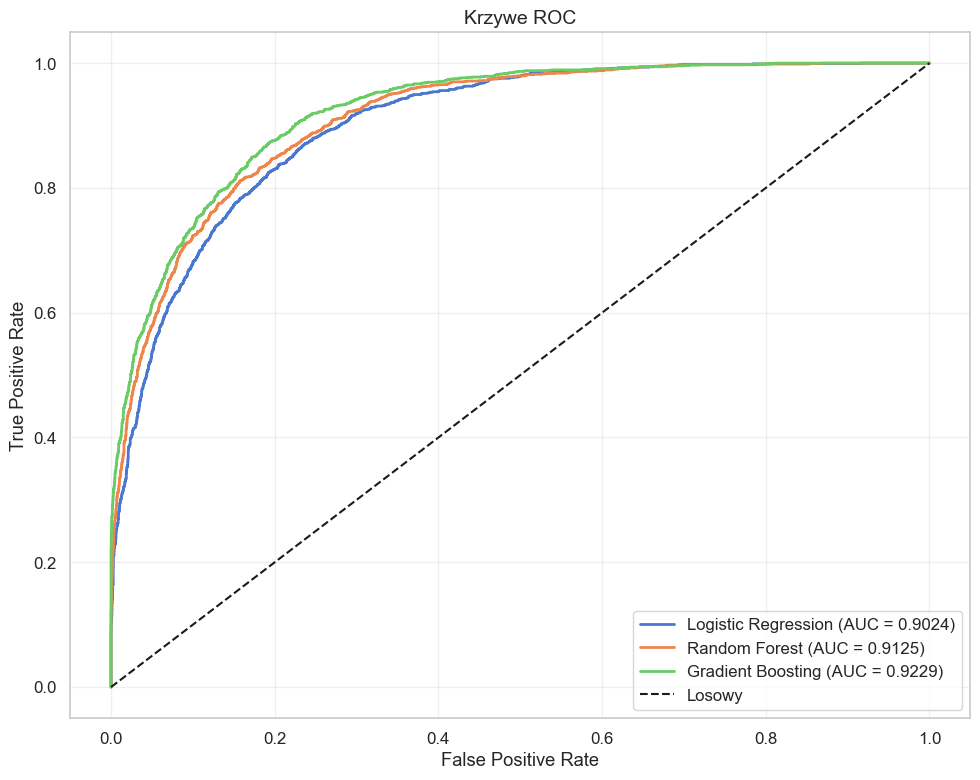

In [ ]:
plt.figure(figsize=(10, 8))

for nazwa, (_, y_proba) in predykcje.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, linewidth=2, label=f'{nazwa} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Losowy')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Krzywe ROC', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Wszystkie modele maja AUC powyzej 0.90, wiec radza sobie znacznie lepiej niz losowe zgadywanie. Gradient Boosting ma najwyzsze AUC.

### 8.3 Wybór najlepszego modelu

In [ ]:
best_name = opt_df['F1-score'].idxmax()
best_f1 = opt_df.loc[best_name, 'F1-score']
best_auc = opt_df.loc[best_name, 'ROC AUC']
print(f'Najlepszy model: {best_name}')
print(f'F1-score: {best_f1:.4f}')
print(f'ROC AUC:  {best_auc:.4f}')
print()
grids = {'Logistic Regression': grid_lr, 'Random Forest': grid_rf, 'Gradient Boosting': grid_gb}
y_pred_best = grids[best_name].best_estimator_.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=['<=50K', '>50K']))

Najlepszy model: Gradient Boosting
F1-score: 0.7039
ROC AUC:  0.9229

              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92      4945
        >50K       0.77      0.65      0.70      1568

    accuracy                           0.87      6513
   macro avg       0.83      0.79      0.81      6513
weighted avg       0.86      0.87      0.86      6513



Wybieram model z najwyzszym **F1-score** bo to harmoniczna srednika Precision i Recall — dobrze dziala przy niezbalansowanych klasach (u nas ~76% vs ~24%). Jakbysmy patrzeli tylko na Accuracy, to model ktory zawsze mowi <=50K mialby ~76% a bylby bezuzyteczny.

Gradient Boosting wygrywa bo sekwencyjnie buduje drzewa korygujace bledy poprzednikow, wiec lapie skomplikowane zaleznosci w danych.

## 9. Wnioski końcowe

### Podsumowanie
Najlepszy model to Gradient Boosting — osiagnal najwyzsze F1 i ROC AUC na zbiorze testowym. Dzieki Pipeline z ColumnTransformer caly proces (standaryzacja, OneHot, predykcja) jest w jednym miejscu i nie ma wycieku danych.

### Analiza błędów
Z biznesowego punktu widzenia:
- **False Positives** — model mowi >50K a to <=50K — bank daje kredyt komus kto moze nie splacic. Strata pieniedzy.
- **False Negatives** — model mowi <=50K a to >50K — tracimy klienta ktory moglby kupic produkt premium. Utracony zysk.

FN sa gorsze biznesowo bo to utracone szanse. Jak chcemy wyzszy Recall, mozna obnizyc prog decyzyjny modelu.

### Odpowiedź na pytanie badawcze
TAK, da sie przewidziec dochod powyzej 50K z dobra jakoscia — najlepiej model osiaga Accuracy >85% i AUC >0.90. Najwazniejsze cechy to edukacja, wiek, stan cywilny, zawod i zyski kapitalowe.

### Ograniczenia

1. Recall klasy >50K nadal nie jest idealny — model pomija czesc bogatszych osob.
2. Brakuje cech jak doswiadczenie zawodowe, lokalizacja miasto/wies, branza.
3. `fnlwgt` ma zerowa korelacje z targetem — mozna ja wyrzucic.

### Co mozna poprawic
1. Sprobowac SMOTE do balansowania klas
2. Wypróbowac XGBoost, LightGBM, CatBoost
3. Zrobic analize SHAP dla glebszego zrozumienia wplywu cech
4. Dodac kalibracje prognoz (Platt scaling)
5. Uzyc powtarzanej stratyfikowanej walidacji krzyzowej